In [1]:
!pip install langchain-google-genai langchain_tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.8 MB/s eta 0:00:00


In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image,display
from langchain_core.tools import tool

In [4]:
import os
os.environ['GEMINI_API_KEY']="xxxxxxxxxxxxxxxxxxxxxx"
# from google.colab import userdata
# userdata.get('GEMINI_API_KEY')

In [5]:
os.environ["TAVILY_API_KEY"] = "xxxxxxxxxxxxxxxxxx"
from langchain_tavily import TavilySearch

In [6]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model= "gemini-2.5-flash",
                            temperature=0.4
                             )

In [8]:
def chatbot(state:State):
  return {"messages":[llm.invoke(state["messages"])]}

In [9]:
@tool
def multiply(a:int,b:int):
  """Multiply a and b
  Args:
      a (int): first int
      b (int): second int
  Returns:
      int: output int
   """

  return a*b

In [14]:
search_tool = TavilySearch(max_results=3)
# tool.invoke("what is langgraph"

In [15]:
tools=[search_tool,multiply]

In [16]:
llm_with_tool=llm.bind_tools(tools)

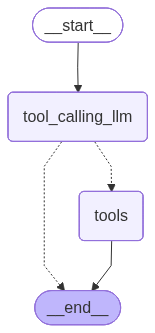

In [17]:
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state:State):
  return {"messages":[llm_with_tool.invoke(state["messages"])]}

#nodes
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

#COMPILE
graph=builder.compile()

#GRAPH VISUALIZATION
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response =graph.invoke({"messages":"what is latest news on iran vs usa & israel war"})
for r in response['messages']:
  r.pretty_print()

================================ Human Message =================================

what is latest news on iran vs usa & israel war
================================== Ai Message ==================================
Tool Calls:
  tavily_search (6a131e2f-dadd-4479-92fa-f70e1aaa2464)
 Call ID: 6a131e2f-dadd-4479-92fa-f70e1aaa2464
  Args:
    query: latest news on Iran vs USA & Israel war
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news on Iran vs USA & Israel war", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.independent.co.uk/news/world/middle-east/iran-us-war-live-trump-strait-of-hormuz-beirut-bombing-b2971953.html", "title": "Iran-US war latest: Trump says war will be ‘over quickly’ as Israel hits Beirut for first time since ceasefire - The Independent", "score": 0.82895297, "published_date": "Thu, 07 May 2026 06:30:02 GMT", "content": "# Iran-US war la

In [20]:
response = graph.invoke({"messages":"give the recent ai news & multiply 10 by 10"})
for r in response['messages']:
  r.pretty_print()

================================ Human Message =================================

give the recent ai news & multiply 10 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (a17a8731-e2fe-4acf-a94c-c6c4c2fe08f1)
 Call ID: a17a8731-e2fe-4acf-a94c-c6c4c2fe08f1
  Args:
    time_range: week
    topic: news
    query: AI news
  multiply (312c72b6-14c2-4470-afe5-8db76b932587)
 Call ID: 312c72b6-14c2-4470-afe5-8db76b932587
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://tvnewscheck.com/programming/article/brilliant-minds-stumble-canceled-by-nbc/", "title": "‘Brilliant Minds’ & ‘Stumble’ Canceled By NBC - TV News Check", "score": 0.9688562, "published_date": "Fri, 01 May 2026 23:44:02 GMT", "content": "‘Brilliant Minds’ & ‘Stumble’ Canceled By N